## 1. Setup and Shared Model Pools

In [2]:
from pathlib import Path
import sys

def _find_project_root(start=None):
    """Find the project root by walking upward from the current directory."""
    path = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (path, *path.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find pyproject.toml above the current directory.")

PROJECT_ROOT = _find_project_root()
PAPER_DIR = PROJECT_ROOT / "paper"
CACHE_DIR = PAPER_DIR / ".cache"
IMAGES_DIR = PAPER_DIR / ".images"
DATA_DIR = PAPER_DIR / "data"
for _dir in (CACHE_DIR, IMAGES_DIR, DATA_DIR):
    _dir.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

%matplotlib inline

import pandas as pd
import numpy as np
import sys
import os
import time
import importlib
import matplotlib.pyplot as plt
from aims4pt.model_tools.model_registry import  get_models_initial_pools, print_all_registered_thermobarometry, ALL_MODELS_MODULES
from aims4pt.toolkit_utils import get_file_path
for module in ALL_MODELS_MODULES:
    importlib.import_module(module)



calculate_shap = False # make sure this to False when not needed, as it takes time and memory




## 2. Loading and Preparing Merapi Data

In [3]:
from aims4pt.model_tools.CpxTBSelect import workflow_thermobarometry
cpx_raw_path = os.path.join(DATA_DIR, "merapi_cpx_raw.xlsx")
liq_raw_path = os.path.join(DATA_DIR, "merapi_liq.xlsx")
cpx_raw = pd.read_excel(cpx_raw_path)
liq_raw = pd.read_excel(liq_raw_path)
cpx_raw.columns = cpx_raw.columns.str.strip()  
liq_raw.columns = liq_raw.columns.str.strip()
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
cpx_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO',
       'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', 'Cr2O3', 'NiO']
# Set water content (following Scruggs and Putirka, 2018)
# Liq_Comp['H2O_Liq']=Liq_Comp['SiO2_Liq']*0.06995+0.383
cpx_raw.keys()

Index(['Sample_id', 'Eruption', 'Source', 'Rim/core', 'SiO2', 'TiO2', 'Al2O3',
       'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', 'Cr2O3', 'NiO', 'F', 'Cl',
       'TOTAL', '(Ca+Fe+Mg)/Si', 'cpx/opx'],
      dtype='object')

Before cleaning, number of cpx samples: 530
After cpx classification, number of cpx samples: 518
After checking total, number of cpx samples: 480
After cpx stoichiometry check, number of cpx samples: 475


,Sample_id,Eruption,Source,Rim/core,SiO2,TiO2,Al2O3,FeO,MnO,MgO,CaO,Na2O,K2O,Cr2O3,NiO,F,Cl,TOTAL,(Ca+Fe+Mg)/Si,cpx/opx
0,2006px2 Line 001,2006,"Li et al., 2021",rim,50.742922,0.675655,3.419136,9.256879,0.628818,14.746829,20.014550,0.427517,0.030893,NaN,NaN,0.083710,0.009965,100.036872,1.008423,NaN
1,2006px2 Line 002,2006,"Li et al., 2021",rim,49.958897,0.932331,4.417043,8.972431,0.460150,13.695238,21.117794,0.411028,0.023058,NaN,NaN,0.012030,0.006015,100.006015,1.011768,NaN
2,2006px2 Line 003,2006,"Li et al., 2021",rim,49.069929,1.013068,5.125703,9.046187,0.412471,13.039104,21.861953,0.396374,0.022133,NaN,NaN,0.022133,0.000000,100.009054,1.027670,NaN
3,2006px2 Line 004,2006,"Li et al., 2021",rim,48.042978,1.000727,6.222483,9.638688,0.330210,12.317728,22.040231,0.383730,0.013128,NaN,NaN,0.008079,0.006059,100.004039,1.041543,NaN
4,2006px2 Line 005,2006,"Li et al., 2021",rim,49.064653,0.825188,5.260575,9.389521,0.364525,12.899575,21.785371,0.392565,0.015022,NaN,NaN,0.000000,0.004006,100.001001,1.027721,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
470,Un 298 2010-CpxSkull-c1,2010,LI thesis,NaN,51.953300,0.382202,1.668580,8.934350,0.767469,15.338800,20.047700,0.352465,NaN,0.000653,0.011991,NaN,NaN,99.457500,0.997407,NaN
471,Un 299 2010-CpxSkull-c2,2010,LI thesis,NaN,51.316300,0.375957,1.514440,8.941050,0.749842,15.304600,20.101100,0.364818,NaN,0.000000,0.000000,NaN,NaN,98.661900,1.010019,NaN
472,Un 300 2010-CpxSkull-Rim2,2010,LI thesis,rim,47.082500,1.297910,6.205480,9.609230,0.331092,12.300700,21.885100,0.361091,NaN,0.000000,0.003883,NaN,NaN,99.068800,1.058198,NaN
473,Un 301 2010-CpxSkull-Rim3,2010,LI thesis,rim,46.047900,1.521490,7.018780,9.964770,0.298006,11.698400,21.992200,0.357622,NaN,0.006623,0.005107,NaN,NaN,98.910900,1.071423,NaN


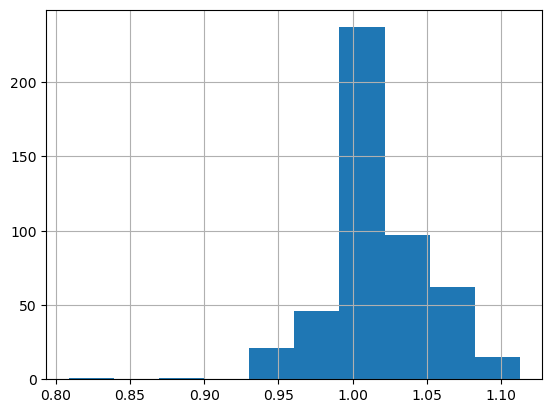

In [4]:
# clean cpx
print("Before cleaning, number of cpx samples:", len(cpx_raw))

# negative value to zero
cpx_raw[cpx_cols] = cpx_raw[cpx_cols].clip(lower=0)
# check if cpx
from aims4pt.data_tools.compositions import pyroxene_classification, cpx_stoichiometry_check

cpx_class = pyroxene_classification(cpx_raw[cpx_cols])
cpx_clean0 = cpx_raw[cpx_class=="Clinopyroxene"] # remove opx samples
print("After cpx classification, number of cpx samples:", len(cpx_clean0))
# total 

cpx_clean1 = cpx_clean0[
    (cpx_clean0["TOTAL"] > 98) & (cpx_clean0["TOTAL"] < 102)
].reset_index(drop=True)
print("After checking total, number of cpx samples:", len(cpx_clean1))

# '(Ca+Fe+Mg)/Si'
cpx_clean1['(Ca+Fe+Mg)/Si'], stio_mask = cpx_stoichiometry_check(cpx_clean1[cpx_cols])
cpx_clean1['(Ca+Fe+Mg)/Si'].hist()
cpx_clean2 = cpx_clean1[stio_mask].reset_index(drop=True)
print("After cpx stoichiometry check, number of cpx samples:", len(cpx_clean2))
cpx_clean2

In [5]:
cpx_06_input = cpx_clean2[cpx_clean2["Eruption"]==2006].reset_index(drop=True)
cpx_06_input


,Sample_id,Eruption,Source,Rim/core,SiO2,TiO2,Al2O3,FeO,MnO,MgO,CaO,Na2O,K2O,Cr2O3,NiO,F,Cl,TOTAL,(Ca+Fe+Mg)/Si,cpx/opx
0,2006px2 Line 001,2006,"Li et al., 2021",rim,50.742922,0.675655,3.419136,9.256879,0.628818,14.746829,20.014550,0.427517,0.030893,NaN,NaN,0.083710,0.009965,100.036872,1.008423,NaN
1,2006px2 Line 002,2006,"Li et al., 2021",rim,49.958897,0.932331,4.417043,8.972431,0.460150,13.695238,21.117794,0.411028,0.023058,NaN,NaN,0.012030,0.006015,100.006015,1.011768,NaN
2,2006px2 Line 003,2006,"Li et al., 2021",rim,49.069929,1.013068,5.125703,9.046187,0.412471,13.039104,21.861953,0.396374,0.022133,NaN,NaN,0.022133,0.000000,100.009054,1.027670,NaN
3,2006px2 Line 004,2006,"Li et al., 2021",rim,48.042978,1.000727,6.222483,9.638688,0.330210,12.317728,22.040231,0.383730,0.013128,NaN,NaN,0.008079,0.006059,100.004039,1.041543,NaN
4,2006px2 Line 005,2006,"Li et al., 2021",rim,49.064653,0.825188,5.260575,9.389521,0.364525,12.899575,21.785371,0.392565,0.015022,NaN,NaN,0.000000,0.004006,100.001001,1.027721,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,Un 159 2006pair-clB-cpx-rim-W,2006,LI thesis,NaN,51.637700,0.359146,1.598750,8.708690,0.696622,15.158300,20.371000,0.390285,NaN,0.007531,0.010138,NaN,NaN,98.938200,1.001345,NaN
166,Un 160 2006pair-clB-cpx-CORE1,2006,LI thesis,NaN,51.437700,0.409381,1.926880,8.708280,0.615156,15.110400,20.188000,0.356576,NaN,0.000000,0.020000,NaN,NaN,98.765400,1.000032,NaN
167,Un 161 2006pair-clB-cpx-CORE2,2006,LI thesis,NaN,51.680400,0.338079,1.557080,9.108510,0.726193,14.964400,20.155600,0.369271,NaN,0.000000,0.000000,NaN,NaN,98.885900,0.996929,NaN
168,Un 163 2006pair-clB-cpx-99E,2006,LI thesis,NaN,51.210300,0.355892,1.568620,8.778750,0.705213,14.858700,20.290900,0.365352,NaN,0.000000,0.002530,NaN,NaN,98.129900,1.000449,NaN


In [6]:
cpx_10_input = cpx_clean2[cpx_clean2["Eruption"]==2010].reset_index(drop=True)
cpx_10_input

,Sample_id,Eruption,Source,Rim/core,SiO2,TiO2,Al2O3,FeO,MnO,MgO,CaO,Na2O,K2O,Cr2O3,NiO,F,Cl,TOTAL,(Ca+Fe+Mg)/Si,cpx/opx
0,2010-cpx1 Line 002,2010,"Li et al., 2021",rim,46.944338,1.620366,7.250910,10.177828,0.348012,12.059705,21.104987,0.414395,0.074430,NaN,NaN,0.000000,0.006035,100.001006,1.045983,NaN
1,2010-cpx1 Line 003,2010,"Li et al., 2021",rim,45.889246,1.790232,8.059587,10.460056,0.270205,11.393122,21.696318,0.392657,0.048576,NaN,NaN,0.000000,0.000000,100.000000,1.067328,NaN
2,2010-cpx1 Line 004,2010,"Li et al., 2021",rim,46.054772,1.771846,8.817550,10.425731,0.281584,10.557882,21.597609,0.461513,0.026430,NaN,NaN,0.009149,0.000000,100.004066,1.033536,NaN
3,2010-cpx1 Line 005,2010,"Li et al., 2021",rim,45.145040,1.826159,8.919170,10.696810,0.324146,10.854754,21.809642,0.367503,0.029937,NaN,NaN,0.043357,0.002065,100.018582,1.074221,NaN
4,2010-cpx1 Line 006,2010,"Li et al., 2021",rim,45.275865,1.719797,8.928589,10.595812,0.203221,10.994166,21.870040,0.371056,0.034376,NaN,NaN,0.004044,0.006066,100.003033,1.075271,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300,Un 298 2010-CpxSkull-c1,2010,LI thesis,NaN,51.953300,0.382202,1.668580,8.934350,0.767469,15.338800,20.047700,0.352465,NaN,0.000653,0.011991,NaN,NaN,99.457500,0.997407,NaN
301,Un 299 2010-CpxSkull-c2,2010,LI thesis,NaN,51.316300,0.375957,1.514440,8.941050,0.749842,15.304600,20.101100,0.364818,NaN,0.000000,0.000000,NaN,NaN,98.661900,1.010019,NaN
302,Un 300 2010-CpxSkull-Rim2,2010,LI thesis,rim,47.082500,1.297910,6.205480,9.609230,0.331092,12.300700,21.885100,0.361091,NaN,0.000000,0.003883,NaN,NaN,99.068800,1.058198,NaN
303,Un 301 2010-CpxSkull-Rim3,2010,LI thesis,rim,46.047900,1.521490,7.018780,9.964770,0.298006,11.698400,21.992200,0.357622,NaN,0.006623,0.005107,NaN,NaN,98.910900,1.071423,NaN


## 3. equilibrium liquid Mg# 

(array([ 5.,  2.,  5., 10., 20., 31., 49., 32., 13.,  3.]),
 array([0.38334252, 0.39554374, 0.40774496, 0.41994618, 0.4321474 ,
        0.44434861, 0.45654983, 0.46875105, 0.48095227, 0.49315349,
        0.5053547 ]),
 <BarContainer object of 10 artists>)

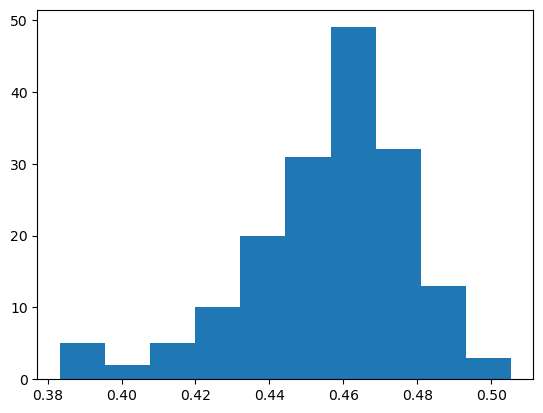

In [7]:
from aims4pt.data_tools.equilibrium import predict_equilibrium_liquid_from_mineral, calculate_mg_number

liq_06_mg_28 = predict_equilibrium_liquid_from_mineral(
    cpx_06_input,
    kd=0.28
)
plt.hist(liq_06_mg_28)

In [8]:
liq_cols = ['SiO2', 'TiO2',
       'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']

liq_2006 = liq_raw[liq_raw["Eruption"]==2006].reset_index(drop=True)
liq_2010 = liq_raw[liq_raw["Eruption"]==2010].reset_index(drop=True)

liq_2010["Mg#"] = calculate_mg_number(liq_2010)
liq_2010.describe()
# 0.145-0.363

,Eruption,SiO2,TiO2,Al2O3,FeO,MnO,MgO,CaO,Na2O,K2O,F,Cl,P2O5,Total,Mg#
count,13.0,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,7.000000,7.000000,6.000000,13.000000,13.000000
mean,2010.0,62.293154,0.606615,16.780615,5.243308,0.162308,1.382000,4.569769,3.786154,4.012846,0.099286,0.177429,0.321667,99.083846,0.279587
std,0.0,6.808170,0.155964,2.310657,2.643158,0.041456,1.044353,3.763040,0.175787,1.854540,0.039276,0.013049,0.004082,1.396893,0.085406
min,2010.0,54.900000,0.378000,14.448000,2.582000,0.107000,0.248000,1.001000,3.378000,2.040000,0.028000,0.160000,0.320000,97.578000,0.145176
25%,2010.0,55.400000,0.476000,14.811000,2.907000,0.118000,0.434000,1.268000,3.740000,2.130000,0.081500,0.169500,0.320000,97.818000,0.194647
50%,2010.0,67.371000,0.619000,14.887000,3.360000,0.175000,0.836000,1.478000,3.795000,5.379000,0.107000,0.173000,0.320000,98.265000,0.334337
75%,2010.0,68.489000,0.740000,19.160000,7.790000,0.200000,2.360000,8.300000,3.890000,5.648000,0.128000,0.186000,0.320000,100.300000,0.353015
max,2010.0,69.173000,0.780000,19.260000,8.370000,0.202000,2.600000,8.710000,4.103000,5.897000,0.141000,0.198000,0.330000,100.900000,0.363480


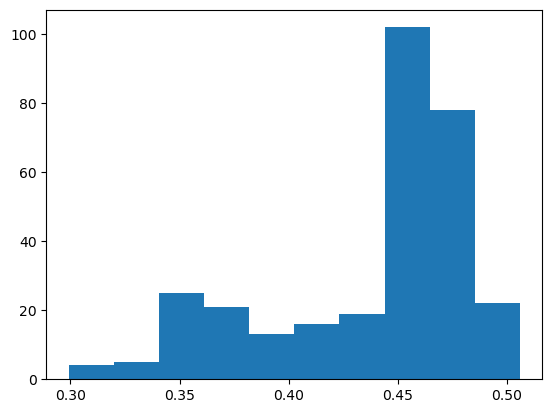

In [9]:
from aims4pt.data_tools.equilibrium import predict_equilibrium_liquid_from_mineral, calculate_mg_number

liq_10_mg_28 = predict_equilibrium_liquid_from_mineral(
    cpx_10_input,
    kd=0.28
)
plt.hist(liq_10_mg_28)
cpx_10_ = cpx_10_input.copy()
cpx_10_["Mg# (kd = 0.28)"] = liq_10_mg_28
cpx_10_["Mg# (kd = 0.36)"] = predict_equilibrium_liquid_from_mineral(
    cpx_10_input,
    kd=0.36
)

cpx_10_["Mg# (kd = 0.20)"] = predict_equilibrium_liquid_from_mineral(
    cpx_10_input,
    kd=0.20
)
# 0.145-0.363
# find a point that "Mg# (kd = 0.20)" , "Mg# (kd = 0.36)" both fall in the range of 0.145-0.363
target_cpx_df = cpx_10_[ (cpx_10_["Mg# (kd = 0.20)"] > 0.145) & (cpx_10_["Mg# (kd = 0.20)"] < 0.363) & (cpx_10_["Mg# (kd = 0.36)"] > 0.145) & (cpx_10_["Mg# (kd = 0.36)"] < 0.363) ]

In [10]:
target_cpx_df

,Sample_id,Eruption,Source,Rim/core,SiO2,TiO2,Al2O3,FeO,MnO,MgO,...,Cr2O3,NiO,F,Cl,TOTAL,(Ca+Fe+Mg)/Si,cpx/opx,Mg# (kd = 0.28),Mg# (kd = 0.36),Mg# (kd = 0.20)
11,2010-cpx1 Line 013,2010,"Li et al., 2021",rim,44.437075,1.969533,9.628602,11.459464,0.222075,9.928052,...,NaN,NaN,0.0,0.002010,100.000000,1.077335,NaN,0.301877,0.357310,0.235980
12,2010-cpx1 Line 014,2010,"Li et al., 2021",rim,44.742264,1.701745,9.536843,11.527430,0.294902,9.866082,...,NaN,NaN,0.0,0.007070,100.002020,1.067805,NaN,0.299317,0.354519,0.233792
13,2010-cpx1 Line 015,2010,"Li et al., 2021",rim,44.905531,1.631959,9.108003,11.701240,0.240319,10.130617,...,NaN,NaN,0.0,0.003017,100.001006,1.074643,NaN,0.301734,0.357153,0.235857


## 4. get all possible pairs for target_cpx

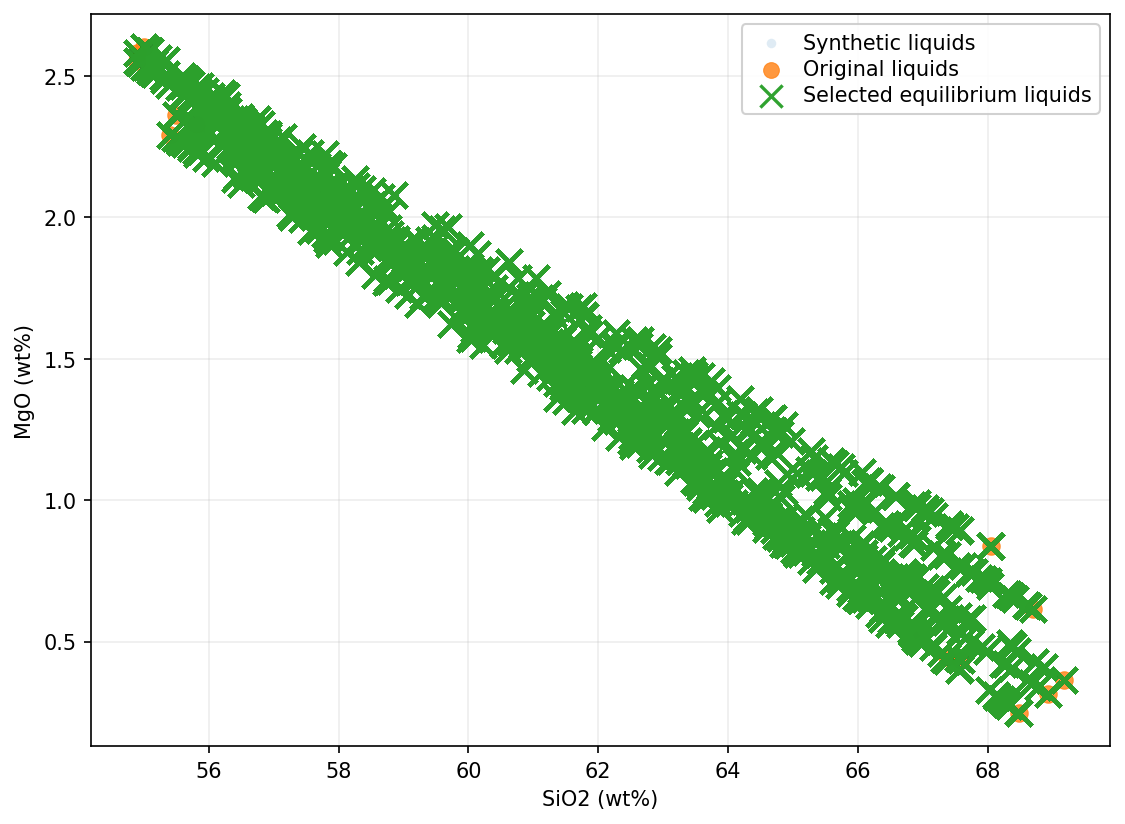

60661

In [11]:
from aims4pt.data_tools.eq_pairing import pair_mineral_liquid_by_kd
res_10 = pair_mineral_liquid_by_kd(
    X_mine=cpx_10_,
    X_liq=liq_2010[liq_cols],     # Defines the expected column set/order.
    one_to_one=False,
    interpolate_liq=True,
    interp_mode="endmembers",
    n_synth=1000,
    endmember1=liq_2010[liq_2010['glass/bulk']=="bulk"][liq_cols], # bulk
    endmember2=liq_2010[liq_2010['glass/bulk']=="glass"][liq_cols], # glass
    random_state=42,

)
paired_cpx_10, paired_liq_10 = res_10.cleaned_minerals, res_10.cleaned_liquids
paired_cpx_10_pass = paired_cpx_10[res_10.pairs_pass_mask].reset_index(drop=True)
paired_liq_10_pass = paired_liq_10[res_10.pairs_pass_mask].reset_index(drop=True)



len(paired_cpx_10_pass)


In [ ]:
from aims4pt.data_tools.eq_pairing import pair_mineral_liquid_by_kd
res_10 = pair_mineral_liquid_by_kd(
    X_mine=cpx_10_,
    X_liq=liq_2010[liq_cols],     # Defines the expected column set/order.
    one_to_one=False,
    interpolate_liq=True,
    interp_mode="endmembers",
    n_synth=1000,
    endmember1=liq_2010[liq_2010['glass/bulk']=="bulk"][liq_cols], # bulk
    endmember2=liq_2010[liq_2010['glass/bulk']=="glass"][liq_cols], # glass
    random_state=42,

)
paired_cpx_10, paired_liq_10 = res_10.cleaned_minerals, res_10.cleaned_liquids
paired_cpx_10_pass = paired_cpx_10[res_10.pairs_pass_mask].reset_index(drop=True)
paired_liq_10_pass = paired_liq_10[res_10.pairs_pass_mask].reset_index(drop=True)



len(paired_cpx_10_pass)


In [12]:
res_10.pairs[res_10.pairs_pass_mask]["kd_value"]

0         0.252428
1         0.252305
2         0.258331
3         0.270362
4         0.260143
            ...   
307947    0.255993
307948    0.228442
307949    0.251760
307950    0.256072
307951    0.229500
Name: kd_value, Length: 60661, dtype: float64

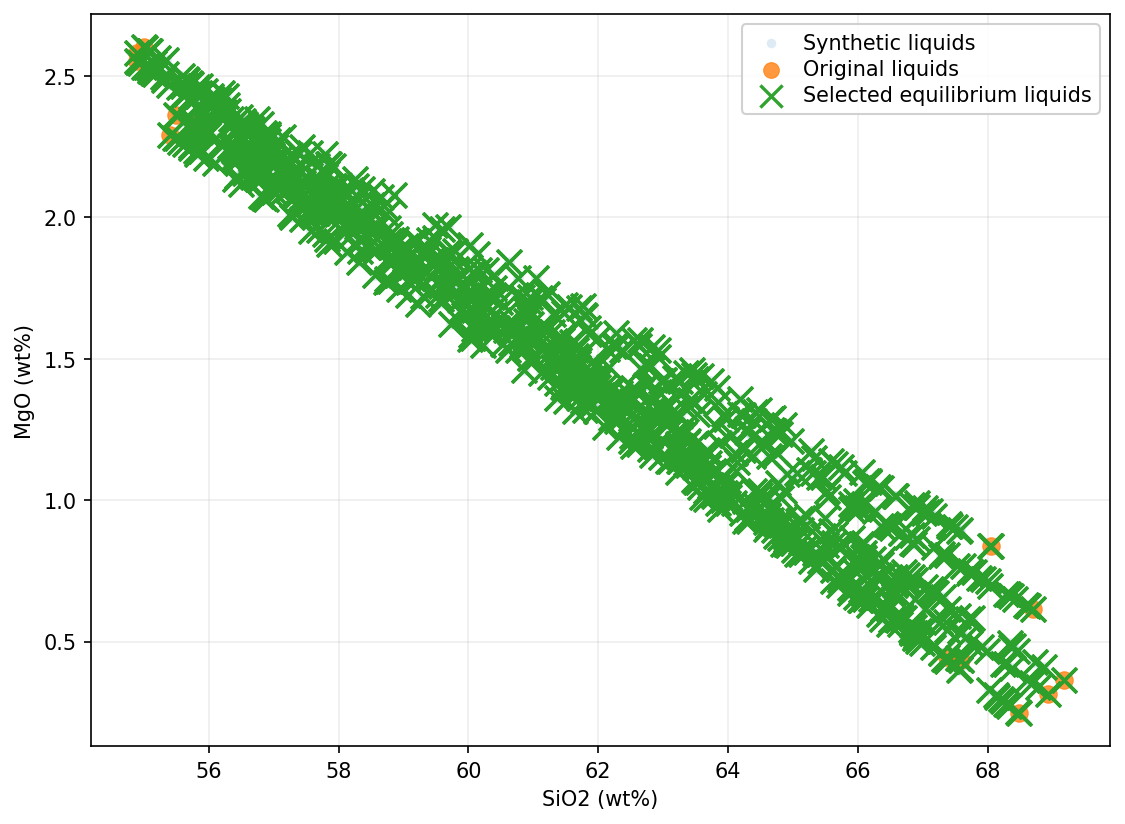

2680

In [ ]:
from aims4pt.data_tools.eq_pairing import pair_mineral_liquid_by_kd
res_10 = pair_mineral_liquid_by_kd(
    X_mine=target_cpx_df,
    X_liq=liq_2010[liq_cols],     # Defines the expected column set/order.
    one_to_one=False,
    interpolate_liq=True,
    interp_mode="endmembers",
    n_synth=1000,
    endmember1=liq_2010[liq_2010['glass/bulk']=="bulk"][liq_cols], # bulk
    endmember2=liq_2010[liq_2010['glass/bulk']=="glass"][liq_cols], # glass
    random_state=42,

)
paired_cpx_10, paired_liq_10 = res_10.cleaned_minerals, res_10.cleaned_liquids
paired_cpx_10_pass = paired_cpx_10[res_10.pairs_pass_mask].reset_index(drop=True)
paired_liq_10_pass = paired_liq_10[res_10.pairs_pass_mask].reset_index(drop=True)



len(paired_cpx_10_pass)


In [11]:
paired_cpx_10_pass

,Sample_id,Eruption,Source,Rim/core,SiO2,TiO2,Al2O3,FeO,MnO,MgO,...,Cr2O3,NiO,F,Cl,TOTAL,(Ca+Fe+Mg)/Si,cpx/opx,Mg# (kd = 0.28),Mg# (kd = 0.36),Mg# (kd = 0.20)
0,2010-cpx1 Line 013,2010,"Li et al., 2021",rim,44.437075,1.969533,9.628602,11.459464,0.222075,9.928052,...,NaN,NaN,0.0,0.002010,100.000000,1.077335,NaN,0.301877,0.357310,0.235980
1,2010-cpx1 Line 013,2010,"Li et al., 2021",rim,44.437075,1.969533,9.628602,11.459464,0.222075,9.928052,...,NaN,NaN,0.0,0.002010,100.000000,1.077335,NaN,0.301877,0.357310,0.235980
2,2010-cpx1 Line 013,2010,"Li et al., 2021",rim,44.437075,1.969533,9.628602,11.459464,0.222075,9.928052,...,NaN,NaN,0.0,0.002010,100.000000,1.077335,NaN,0.301877,0.357310,0.235980
3,2010-cpx1 Line 013,2010,"Li et al., 2021",rim,44.437075,1.969533,9.628602,11.459464,0.222075,9.928052,...,NaN,NaN,0.0,0.002010,100.000000,1.077335,NaN,0.301877,0.357310,0.235980
4,2010-cpx1 Line 013,2010,"Li et al., 2021",rim,44.437075,1.969533,9.628602,11.459464,0.222075,9.928052,...,NaN,NaN,0.0,0.002010,100.000000,1.077335,NaN,0.301877,0.357310,0.235980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2675,2010-cpx1 Line 015,2010,"Li et al., 2021",rim,44.905531,1.631959,9.108003,11.701240,0.240319,10.130617,...,NaN,NaN,0.0,0.003017,100.001006,1.074643,NaN,0.301734,0.357153,0.235857
2676,2010-cpx1 Line 015,2010,"Li et al., 2021",rim,44.905531,1.631959,9.108003,11.701240,0.240319,10.130617,...,NaN,NaN,0.0,0.003017,100.001006,1.074643,NaN,0.301734,0.357153,0.235857
2677,2010-cpx1 Line 015,2010,"Li et al., 2021",rim,44.905531,1.631959,9.108003,11.701240,0.240319,10.130617,...,NaN,NaN,0.0,0.003017,100.001006,1.074643,NaN,0.301734,0.357153,0.235857
2678,2010-cpx1 Line 015,2010,"Li et al., 2021",rim,44.905531,1.631959,9.108003,11.701240,0.240319,10.130617,...,NaN,NaN,0.0,0.003017,100.001006,1.074643,NaN,0.301734,0.357153,0.235857


In [12]:
paired_liq_10_pass

,mine__pair_mine_id,liq__pair_liq_id,liq__pair_row_idx,SiO2,TiO2,Al2O3,FeO,MnO,MgO,CaO,Na2O,K2O,liq__is_synthetic,liq__mix_f,liq__endmember1_idx,liq__endmember2_idx
0,11,0,0,55.800000,0.740000,19.250000,7.790000,0.200000,2.330000,8.270000,3.900000,2.160000,False,NaN,NaN,NaN
1,11,1,1,55.400000,0.730000,19.160000,7.660000,0.200000,2.290000,8.250000,3.890000,2.130000,False,NaN,NaN,NaN
2,11,2,2,55.500000,0.740000,19.140000,7.710000,0.200000,2.360000,8.300000,3.900000,2.130000,False,NaN,NaN,NaN
3,11,4,4,54.900000,0.780000,19.260000,8.370000,0.200000,2.580000,8.670000,3.740000,2.040000,False,NaN,NaN,NaN
4,11,9,9,68.697000,0.476000,14.448000,2.907000,0.125000,0.614000,1.024000,3.378000,5.759000,False,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2675,13,1008,1008,58.355090,0.680865,17.947878,6.653015,0.177839,1.999431,6.743979,3.738443,3.004782,True,0.753771,3.0,0.0
2676,13,1009,1009,64.763166,0.559826,15.760133,4.347723,0.146384,1.165997,3.189790,3.498322,4.704332,True,0.285122,3.0,3.0
2677,13,1010,1010,63.845827,0.574427,16.277377,4.556127,0.183376,1.346611,3.658627,3.827520,4.290433,True,0.335047,2.0,6.0
2678,13,1011,1011,56.908853,0.741116,18.514318,7.542634,0.195828,2.267482,7.594098,3.787554,2.587613,True,0.845699,5.0,1.0


## 5. Initial interested thermobarometry models


In [13]:
from aims4pt.model_tools.Jorgenson22 import Jorgenson22
from aims4pt.model_tools.Agreda2024 import Agreda2024
from aims4pt.model_tools.Higgins21 import Higgins21
from aims4pt.model_tools.Chicchi23 import Chicchi23

P_only_jorgenson22 = Jorgenson22("P", True)
P_liq_agreda2024 = Agreda2024("P", False)
T_only_higgins21 = Higgins21("T")
T_liq_chicchi23 = Chicchi23("T", False)


c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator OneClassSVM from version 1.7.2 when using ver

In [14]:
paired_liq_10_pass["H2O"] = paired_liq_10_pass['SiO2']*0.06995+0.383

In [15]:
res_10.pairs[res_10.pairs_pass_mask]

,mine__Sample_id,mine__Eruption,mine__Source,mine__Rim/core,mine__SiO2,mine__TiO2,mine__Al2O3,mine__FeO,mine__MnO,mine__MgO,...,liq__liq__mix_f,liq__liq__endmember1_idx,liq__liq__endmember2_idx,mine__pair_mine_id,liq__pair_liq_id,mine__pair_row_idx,liq__pair_row_idx,kd_value,kd_error,if_pass_test
0,2010-cpx1 Line 013,2010,"Li et al., 2021",rim,44.437075,1.969533,9.628602,11.459464,0.222075,9.928052,...,NaN,NaN,NaN,11,0,0,0,0.345238,0.065238,True
1,2010-cpx1 Line 013,2010,"Li et al., 2021",rim,44.437075,1.969533,9.628602,11.459464,0.222075,9.928052,...,NaN,NaN,NaN,11,1,0,1,0.345070,0.065070,True
2,2010-cpx1 Line 013,2010,"Li et al., 2021",rim,44.437075,1.969533,9.628602,11.459464,0.222075,9.928052,...,NaN,NaN,NaN,11,2,0,2,0.353312,0.073312,True
4,2010-cpx1 Line 013,2010,"Li et al., 2021",rim,44.437075,1.969533,9.628602,11.459464,0.222075,9.928052,...,NaN,NaN,NaN,11,4,0,4,0.355791,0.075791,True
9,2010-cpx1 Line 013,2010,"Li et al., 2021",rim,44.437075,1.969533,9.628602,11.459464,0.222075,9.928052,...,NaN,NaN,NaN,11,9,0,9,0.243794,0.036206,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3034,2010-cpx1 Line 015,2010,"Li et al., 2021",rim,44.905531,1.631959,9.108003,11.701240,0.240319,10.130617,...,0.753771,3.0,0.0,13,1008,2,1008,0.347123,0.067123,True
3035,2010-cpx1 Line 015,2010,"Li et al., 2021",rim,44.905531,1.631959,9.108003,11.701240,0.240319,10.130617,...,0.285122,3.0,3.0,13,1009,2,1009,0.309764,0.029764,True
3036,2010-cpx1 Line 015,2010,"Li et al., 2021",rim,44.905531,1.631959,9.108003,11.701240,0.240319,10.130617,...,0.335047,2.0,6.0,13,1010,2,1010,0.341383,0.061383,True
3037,2010-cpx1 Line 015,2010,"Li et al., 2021",rim,44.905531,1.631959,9.108003,11.701240,0.240319,10.130617,...,0.845699,5.0,1.0,13,1011,2,1011,0.347230,0.067230,True


In [16]:
paired_cpx_10_pass

,Sample_id,Eruption,Source,Rim/core,SiO2,TiO2,Al2O3,FeO,MnO,MgO,...,Cr2O3,NiO,F,Cl,TOTAL,(Ca+Fe+Mg)/Si,cpx/opx,Mg# (kd = 0.28),Mg# (kd = 0.36),Mg# (kd = 0.20)
0,2010-cpx1 Line 013,2010,"Li et al., 2021",rim,44.437075,1.969533,9.628602,11.459464,0.222075,9.928052,...,NaN,NaN,0.0,0.002010,100.000000,1.077335,NaN,0.301877,0.357310,0.235980
1,2010-cpx1 Line 013,2010,"Li et al., 2021",rim,44.437075,1.969533,9.628602,11.459464,0.222075,9.928052,...,NaN,NaN,0.0,0.002010,100.000000,1.077335,NaN,0.301877,0.357310,0.235980
2,2010-cpx1 Line 013,2010,"Li et al., 2021",rim,44.437075,1.969533,9.628602,11.459464,0.222075,9.928052,...,NaN,NaN,0.0,0.002010,100.000000,1.077335,NaN,0.301877,0.357310,0.235980
3,2010-cpx1 Line 013,2010,"Li et al., 2021",rim,44.437075,1.969533,9.628602,11.459464,0.222075,9.928052,...,NaN,NaN,0.0,0.002010,100.000000,1.077335,NaN,0.301877,0.357310,0.235980
4,2010-cpx1 Line 013,2010,"Li et al., 2021",rim,44.437075,1.969533,9.628602,11.459464,0.222075,9.928052,...,NaN,NaN,0.0,0.002010,100.000000,1.077335,NaN,0.301877,0.357310,0.235980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2675,2010-cpx1 Line 015,2010,"Li et al., 2021",rim,44.905531,1.631959,9.108003,11.701240,0.240319,10.130617,...,NaN,NaN,0.0,0.003017,100.001006,1.074643,NaN,0.301734,0.357153,0.235857
2676,2010-cpx1 Line 015,2010,"Li et al., 2021",rim,44.905531,1.631959,9.108003,11.701240,0.240319,10.130617,...,NaN,NaN,0.0,0.003017,100.001006,1.074643,NaN,0.301734,0.357153,0.235857
2677,2010-cpx1 Line 015,2010,"Li et al., 2021",rim,44.905531,1.631959,9.108003,11.701240,0.240319,10.130617,...,NaN,NaN,0.0,0.003017,100.001006,1.074643,NaN,0.301734,0.357153,0.235857
2678,2010-cpx1 Line 015,2010,"Li et al., 2021",rim,44.905531,1.631959,9.108003,11.701240,0.240319,10.130617,...,NaN,NaN,0.0,0.003017,100.001006,1.074643,NaN,0.301734,0.357153,0.235857


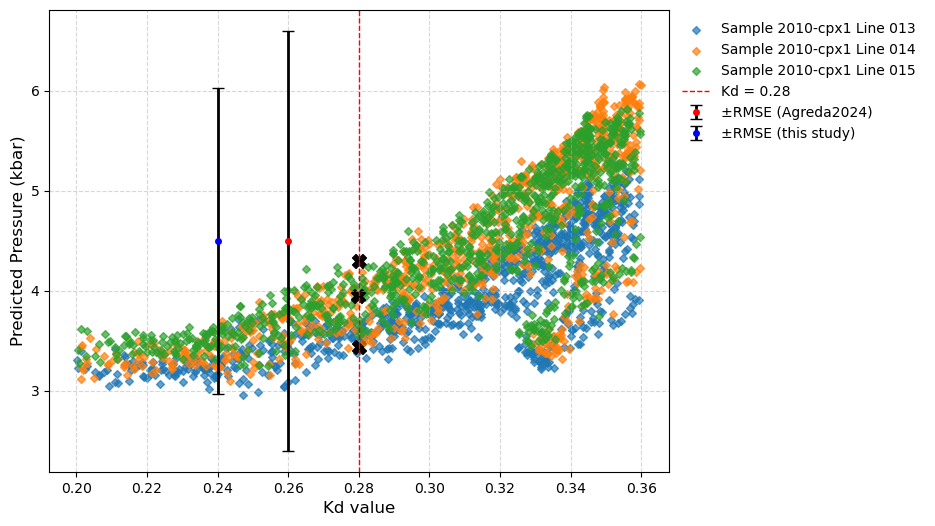

In [36]:
P_liq_predictions = P_liq_agreda2024.predict(paired_cpx_10_pass, paired_liq_10_pass)
P_liq_kd_values = res_10.pairs[res_10.pairs_pass_mask]["kd_value"].reset_index(drop=True)
P_liq_sum_df = pd.DataFrame({
    "Predicted_P": P_liq_predictions,
    "Kd_value": P_liq_kd_values,
    "kd_error": res_10.pairs[res_10.pairs_pass_mask]["kd_error"].reset_index(drop=True)
})
P_liq_sum_df = pd.concat([paired_cpx_10_pass, paired_liq_10_pass, P_liq_sum_df], axis=1)
P_liq_sum_df
# plot kd values vs predicted P

# group by Sample_id
P_liq_sum_grouped = P_liq_sum_df.groupby("Sample_id")

fig, ax = plt.subplots(figsize=(8, 6))
for sample_id, group in P_liq_sum_grouped:
    # get the data with the lowest abs (kd_error) 
    
    ax.scatter(group["Kd_value"], group["Predicted_P"], label=f"Sample {sample_id}", alpha=0.7)
    ax.set_xlabel("Kd value")
    ax.set_ylabel("Predicted Pressure (kbar)")
    kd_error_min_point = group.loc[group["kd_error"].abs().idxmin()]
    ax.scatter(kd_error_min_point["Kd_value"], kd_error_min_point["Predicted_P"], color="black", marker="X", s=100)
    # mark the data close to 0.28
# vertical line at 0.28
ax.axvline(0.28, color="red", linestyle="--", label="Kd = 0.28")
ax.grid( True, linestyle="--", alpha=0.5)
# smallest kd_error point

# uncertainty bar for the point with smallest kd_error
x = 0.26
y = 4.5
yerr = P_liq_agreda2024.uncertainty
# dot at (x, y)
ax.errorbar(x, y, yerr=yerr, fmt="o", color="red", ecolor="black", elinewidth=2, capsize=4, label="±RMSE (Agreda2024)")
x_ = 0.24
y_ = 4.5
yerr_ = 1.53
ax.errorbar(x_, y_, yerr=yerr_, fmt="o", color="blue", ecolor="black", elinewidth=2, capsize=4, label="±RMSE (this study)")
ax.legend()

Diagnostic columns:
{'sample': 'Sample_id', 'glass': 'liq__endmember2_idx', 'bulk': 'liq__endmember1_idx', 'mix_f': 'liq__mix_f'}
Right-side subset: Kd >= 0.328, n = 1155 of 2680


,Sample_id,Kd_value,Predicted_P,kd_error,glass_idx_label,bulk_idx_label,mix_f
712,2010-cpx1 Line 013,0.328042,4.142018,0.048042,0,4,0.686050
879,2010-cpx1 Line 013,0.329315,4.328030,0.049315,0,2,0.734146
312,2010-cpx1 Line 013,0.329507,4.497254,0.049507,0,1,0.810963
330,2010-cpx1 Line 013,0.330104,4.362373,0.050104,0,5,0.668331
152,2010-cpx1 Line 013,0.330639,4.477869,0.050639,0,1,0.823125
423,2010-cpx1 Line 013,0.330641,4.242583,0.050641,0,5,0.672853
616,2010-cpx1 Line 013,0.330781,4.489775,0.050781,0,0,0.820506
24,2010-cpx1 Line 013,0.330986,4.326639,0.050986,0,2,0.749619
373,2010-cpx1 Line 013,0.331272,4.502158,0.051272,0,1,0.830019
773,2010-cpx1 Line 013,0.333046,4.630067,0.053046,0,1,0.849730


,Sample_id,glass_idx_label,bulk_idx_label,n,kd_min,kd_max,P_min,P_max,P_median,mix_f_min,mix_f_max,slope_kbar_per_kd,intercept,r2
5,2010-cpx1 Line 013,0,5,5,0.330104,0.355673,4.242583,4.945027,4.395866,0.668331,0.932780,26.844322,-4.595659,0.934286
1,2010-cpx1 Line 013,0,1,5,0.329507,0.341993,4.477869,4.973746,4.502158,0.810963,0.958515,41.052835,-9.066338,0.978570
3,2010-cpx1 Line 013,0,3,8,0.333514,0.357828,4.137723,4.699877,4.516280,0.644009,0.860570,20.912951,-2.818978,0.881406
2,2010-cpx1 Line 013,0,2,6,0.329315,0.349263,4.326639,4.813721,4.570156,0.734146,0.947536,25.521072,-4.089522,0.979190
0,2010-cpx1 Line 013,0,0,8,0.330781,0.344816,4.489775,5.024398,4.739780,0.820506,0.994078,36.350454,-7.526581,0.949622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,2010-cpx1 Line 015,6,5,19,0.332914,0.359706,3.678678,5.598933,4.158160,0.086711,0.907605,82.334171,-24.339657,0.844258
125,2010-cpx1 Line 015,6,3,12,0.347996,0.359731,3.745238,4.535006,4.206245,0.276207,0.553981,53.285299,-14.710874,0.843626
126,2010-cpx1 Line 015,6,4,23,0.330895,0.355813,3.516418,5.697572,5.029479,0.071305,0.979979,89.832773,-26.501508,0.888912
123,2010-cpx1 Line 015,6,1,19,0.329137,0.345255,3.556986,5.622947,5.231131,0.081154,0.993543,134.629213,-41.060785,0.929803


C:\Users\13493\AppData\Local\Temp\ipykernel_68976\3419353469.py:119: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  bin_pivot = bin_summary.pivot_table(index=["Sample_id", "kd_bin"], columns="glass_idx_label", values="P_median")


glass_idx_label,Sample_id,kd_bin,0,1,2,3,4,5,6,<NA>,P_gap_kbar
8,2010-cpx1 Line 014,"(0.333, 0.338]",5.216389,5.204212,5.195512,4.706895,5.223737,5.327301,3.453877,NaN,1.873424
7,2010-cpx1 Line 014,"(0.327, 0.333]",5.052819,5.067237,4.793405,4.430931,5.165915,5.134929,3.468897,3.564583,1.697017
14,2010-cpx1 Line 015,"(0.327, 0.333]",4.953085,5.048628,4.836388,4.704727,5.187757,5.138631,3.608152,NaN,1.579605
9,2010-cpx1 Line 014,"(0.338, 0.343]",5.311867,5.402835,5.348453,5.094218,5.326404,5.345368,3.905538,NaN,1.497297
15,2010-cpx1 Line 015,"(0.333, 0.338]",5.233144,5.157375,5.056584,4.728346,5.208323,5.190052,3.749062,NaN,1.484081
10,2010-cpx1 Line 014,"(0.343, 0.348]",5.568179,5.409228,5.618633,5.479522,5.493842,5.336179,4.184569,NaN,1.434064
16,2010-cpx1 Line 015,"(0.338, 0.343]",5.487825,5.237950,5.226791,5.295376,5.411654,5.267655,4.109153,NaN,1.378672
1,2010-cpx1 Line 013,"(0.333, 0.338]",4.602880,4.496612,4.436078,4.158080,4.581559,4.474279,3.431048,NaN,1.171833
0,2010-cpx1 Line 013,"(0.327, 0.333]",4.362373,4.387575,4.281271,4.094762,4.502294,4.456937,3.331061,NaN,1.171233
2,2010-cpx1 Line 013,"(0.338, 0.343]",4.730299,4.651521,4.629277,4.587735,4.806744,4.536488,3.750113,NaN,1.056632


Glass rows matched by original liq_2010 index:


,liq__endmember2_idx,glass/bulk,Mg#,SiO2,TiO2,Al2O3,FeO,MnO,MgO,CaO,Na2O,K2O
0,6,glass,0.174274,68.932,0.408,14.574,2.652,0.11,0.314,1.001,3.55,5.897


Glass rows matched by position within the glass-only pool:


,liq__endmember2_idx_as_position,liq_2010_index,glass/bulk,Mg#,SiO2,TiO2,Al2O3,FeO,MnO,MgO,CaO,Na2O,K2O
0,0,6,glass,0.174274,68.932,0.408,14.574,2.652,0.110,0.314,1.001,3.550,5.897
1,1,7,glass,0.194647,67.371,0.528,14.811,3.282,0.162,0.445,1.478,4.103,5.589
2,2,8,glass,0.201269,69.173,0.378,14.887,2.582,0.111,0.365,1.151,3.781,5.648
3,3,9,glass,0.273519,68.697,0.476,14.448,2.907,0.125,0.614,1.024,3.378,5.759
4,4,10,glass,0.145176,68.489,0.619,14.831,2.603,0.118,0.248,1.268,3.862,5.507
5,5,11,glass,0.187154,67.598,0.446,14.712,3.360,0.107,0.434,1.345,3.795,5.828
6,6,12,glass,0.334337,68.051,0.491,14.835,2.967,0.175,0.836,1.320,3.791,5.379


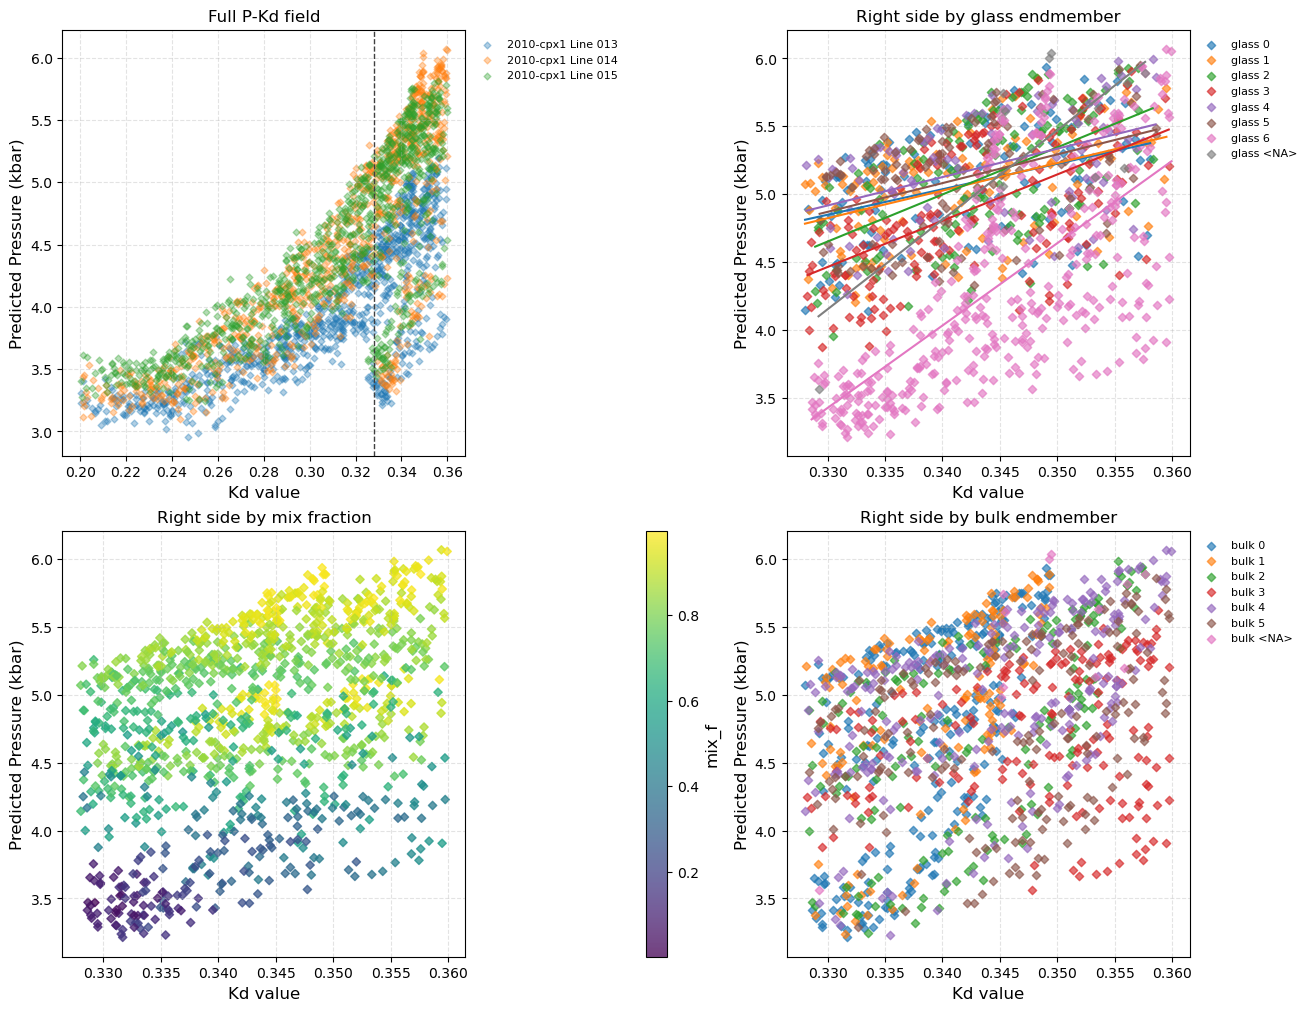

In [42]:
# Right-side hook diagnostic: test whether the apparent two trends follow glass endmembers.
right_kd_min = 0.328  # Adjust this threshold if the hook starts at a different Kd.
bin_width = 0.005


def _find_col(df, suffix, preferred=()):
    """Find one column by exact name or suffix, preferring less-prefixed names."""
    cols = list(df.columns)
    for name in preferred:
        if name in cols:
            return name
    matches = [c for c in cols if str(c) == suffix or str(c).endswith(suffix)]
    if not matches:
        return None
    return sorted(matches, key=lambda c: (str(c).count("__"), len(str(c))))[0]


def _as_series(df, col):
    """Return a single Series even if duplicate column names exist."""
    values = df.loc[:, col]
    if isinstance(values, pd.DataFrame):
        values = values.iloc[:, 0]
    return values


sample_col = _find_col(P_liq_sum_df, "Sample_id", preferred=("Sample_id", "mine__Sample_id"))
glass_col = _find_col(P_liq_sum_df, "endmember2_idx", preferred=("liq__endmember2_idx", "liq__liq__endmember2_idx"))
bulk_col = _find_col(P_liq_sum_df, "endmember1_idx", preferred=("liq__endmember1_idx", "liq__liq__endmember1_idx"))
mix_col = _find_col(P_liq_sum_df, "mix_f", preferred=("liq__mix_f", "liq__liq__mix_f"))
required = {
    "sample_col": sample_col,
    "glass_col": glass_col,
    "bulk_col": bulk_col,
    "mix_col": mix_col,
    "Kd_value": "Kd_value" if "Kd_value" in P_liq_sum_df.columns else None,
    "Predicted_P": "Predicted_P" if "Predicted_P" in P_liq_sum_df.columns else None,
}
missing = [name for name, col in required.items() if col is None]
if missing:
    raise KeyError(f"Missing diagnostic columns: {missing}. Available columns: {list(P_liq_sum_df.columns)}")

print("Diagnostic columns:")
print({"sample": sample_col, "glass": glass_col, "bulk": bulk_col, "mix_f": mix_col})

diag_all = pd.DataFrame({
    "Sample_id": _as_series(P_liq_sum_df, sample_col),
    "Kd_value": _as_series(P_liq_sum_df, "Kd_value"),
    "Predicted_P": _as_series(P_liq_sum_df, "Predicted_P"),
    "kd_error": _as_series(P_liq_sum_df, "kd_error") if "kd_error" in P_liq_sum_df.columns else np.nan,
    "glass_idx": _as_series(P_liq_sum_df, glass_col),
    "bulk_idx": _as_series(P_liq_sum_df, bulk_col),
    "mix_f": _as_series(P_liq_sum_df, mix_col),
})
for col in ["Kd_value", "Predicted_P", "kd_error", "glass_idx", "bulk_idx", "mix_f"]:
    diag_all[col] = pd.to_numeric(diag_all[col], errors="coerce")

diag_all["glass_idx_label"] = diag_all["glass_idx"].astype("Int64").astype(str)
diag_all["bulk_idx_label"] = diag_all["bulk_idx"].astype("Int64").astype(str)
right = diag_all.loc[diag_all["Kd_value"].ge(right_kd_min)].copy()
if right.empty:
    raise ValueError(f"No rows found with Kd_value >= {right_kd_min}; lower right_kd_min.")

print(f"Right-side subset: Kd >= {right_kd_min}, n = {len(right)} of {len(diag_all)}")
display(
    right[["Sample_id", "Kd_value", "Predicted_P", "kd_error", "glass_idx_label", "bulk_idx_label", "mix_f"]]
    .sort_values(["Sample_id", "glass_idx_label", "Kd_value", "Predicted_P"])
    .head(60)
)


def _fit_branch(group):
    """Fit a local P-Kd line for one cpx/glass/bulk branch."""
    clean = group[["Kd_value", "Predicted_P"]].dropna()
    if len(clean) < 2 or clean["Kd_value"].nunique() < 2:
        return {"slope_kbar_per_kd": np.nan, "intercept": np.nan, "r2": np.nan}
    x = clean["Kd_value"].to_numpy()
    y = clean["Predicted_P"].to_numpy()
    slope, intercept = np.polyfit(x, y, 1)
    y_hat = slope * x + intercept
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = np.nan if ss_tot == 0 else 1 - ss_res / ss_tot
    return {"slope_kbar_per_kd": slope, "intercept": intercept, "r2": r2}

branch_keys = ["Sample_id", "glass_idx_label", "bulk_idx_label"]
branch_summary = (
    right.groupby(branch_keys, dropna=False)
    .agg(
        n=("Predicted_P", "size"),
        kd_min=("Kd_value", "min"),
        kd_max=("Kd_value", "max"),
        P_min=("Predicted_P", "min"),
        P_max=("Predicted_P", "max"),
        P_median=("Predicted_P", "median"),
        mix_f_min=("mix_f", "min"),
        mix_f_max=("mix_f", "max"),
    )
    .reset_index()
)
fit_rows = []
for keys, group in right.groupby(branch_keys, dropna=False):
    row = dict(zip(branch_keys, keys if isinstance(keys, tuple) else (keys,)))
    row.update(_fit_branch(group))
    fit_rows.append(row)
branch_summary = (
    branch_summary.merge(pd.DataFrame(fit_rows), on=branch_keys, how="left")
    .sort_values(["Sample_id", "glass_idx_label", "P_median"])
)
display(branch_summary)

# Quantify pressure offsets between glass branches at nearly identical Kd.
kd_bins = np.arange(right_kd_min, right["Kd_value"].max() + bin_width * 1.5, bin_width)
right["kd_bin"] = pd.cut(right["Kd_value"], kd_bins, include_lowest=True)
bin_summary = (
    right.groupby(["Sample_id", "kd_bin", "glass_idx_label"], observed=True, dropna=False)
    .agg(n=("Predicted_P", "size"), P_median=("Predicted_P", "median"), mix_f_median=("mix_f", "median"))
    .reset_index()
)
bin_pivot = bin_summary.pivot_table(index=["Sample_id", "kd_bin"], columns="glass_idx_label", values="P_median")
branch_gap = bin_pivot.assign(P_gap_kbar=bin_pivot.max(axis=1) - bin_pivot.min(axis=1)).reset_index()
display(branch_gap.sort_values("P_gap_kbar", ascending=False).head(20))

# Show the glass compositions that define the synthetic-liquid branches.
used_glass_idx = sorted(right["glass_idx"].dropna().astype(int).unique())
glass_pool = liq_2010.loc[liq_2010["glass/bulk"].eq("glass")].copy()
glass_pool_reset = glass_pool.reset_index().rename(columns={"index": "liq_2010_index"})
glass_cols = [c for c in ["liq_2010_index", "glass/bulk", "Mg#", "SiO2", "TiO2", "Al2O3", "FeO", "MnO", "MgO", "CaO", "Na2O", "K2O"] if c in glass_pool_reset.columns]

matched_by_index = glass_pool.loc[[idx for idx in used_glass_idx if idx in glass_pool.index], [c for c in glass_cols if c != "liq_2010_index"]].copy()
if not matched_by_index.empty:
    matched_by_index.insert(0, "liq__endmember2_idx", matched_by_index.index)
    print("Glass rows matched by original liq_2010 index:")
    display(matched_by_index.reset_index(drop=True))

pos_idx = [idx for idx in used_glass_idx if 0 <= idx < len(glass_pool_reset)]
matched_by_position = glass_pool_reset.iloc[pos_idx][glass_cols].copy() if pos_idx else pd.DataFrame()
if not matched_by_position.empty:
    matched_by_position.insert(0, "liq__endmember2_idx_as_position", pos_idx)
    print("Glass rows matched by position within the glass-only pool:")
    display(matched_by_position.reset_index(drop=True))

if matched_by_index.empty and matched_by_position.empty:
    print("No glass composition rows matched these endmember indices; inspect whether the pairing code rewrites indices.")

# Plot the right hook several ways to see whether it is a glass-endmember split.
fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
axes = axes.ravel()

for sample_id, group in diag_all.groupby("Sample_id"):
    axes[0].scatter(group["Kd_value"], group["Predicted_P"], s=12, alpha=0.35, label=sample_id)
axes[0].axvline(right_kd_min, color="0.25", linestyle="--", linewidth=1)
axes[0].set_title("Full P-Kd field")
axes[0].set_xlabel("Kd value")
axes[0].set_ylabel("Predicted Pressure (kbar)")
axes[0].legend(fontsize=8)

for glass_idx, group in right.groupby("glass_idx_label", dropna=False):
    ordered = group.sort_values("Kd_value")
    axes[1].scatter(ordered["Kd_value"], ordered["Predicted_P"], s=18, alpha=0.65, label=f"glass {glass_idx}")
    if len(ordered) >= 2 and ordered["Kd_value"].nunique() >= 2:
        slope, intercept = np.polyfit(ordered["Kd_value"], ordered["Predicted_P"], 1)
        x_line = np.linspace(ordered["Kd_value"].min(), ordered["Kd_value"].max(), 50)
        axes[1].plot(x_line, slope * x_line + intercept, linewidth=1.5)
axes[1].set_title("Right side by glass endmember")
axes[1].set_xlabel("Kd value")
axes[1].set_ylabel("Predicted Pressure (kbar)")
axes[1].legend(fontsize=8)

sc = axes[2].scatter(right["Kd_value"], right["Predicted_P"], c=right["mix_f"], s=18, alpha=0.75, cmap="viridis")
fig.colorbar(sc, ax=axes[2], label="mix_f")
axes[2].set_title("Right side by mix fraction")
axes[2].set_xlabel("Kd value")
axes[2].set_ylabel("Predicted Pressure (kbar)")

for bulk_idx, group in right.groupby("bulk_idx_label", dropna=False):
    axes[3].scatter(group["Kd_value"], group["Predicted_P"], s=18, alpha=0.65, label=f"bulk {bulk_idx}")
axes[3].set_title("Right side by bulk endmember")
axes[3].set_xlabel("Kd value")
axes[3].set_ylabel("Predicted Pressure (kbar)")
axes[3].legend(fontsize=8)

for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.35)

plt.show()


In [ ]:
T_liq_predictions = T_liq_chicchi23.predict(paired_cpx_10_pass, paired_liq_10_pass)
T_liq_kd_values = res_10.pairs[res_10.pairs_pass_mask]["kd_value"].reset_index(drop=True)
T_liq_sum_df = pd.DataFrame({
    "Predicted_T": T_liq_predictions,
    "Kd_value": T_liq_kd_values,
    "kd_error": res_10.pairs[res_10.pairs_pass_mask]["kd_error"].reset_index(drop=True)
})
T_liq_sum_df = pd.concat([paired_cpx_10_pass, paired_liq_10_pass, T_liq_sum_df], axis=1)
T_liq_sum_df
# plot kd values vs predicted P

# group by Sample_id
T_liq_sum_grouped = T_liq_sum_df.groupby("Sample_id")

fig, ax = plt.subplots(figsize=(8, 6))
for sample_id, group in T_liq_sum_grouped:
    # get the data with the lowest abs (kd_error) 
    
    ax.scatter(group["Kd_value"], group["Predicted_T"], label=f"Sample {sample_id}", alpha=0.7)
    ax.set_xlabel("Kd value")
    ax.set_ylabel("Predicted Temperature (°C)")
    kd_error_min_point = group.loc[group["kd_error"].abs().idxmin()]
    ax.scatter(kd_error_min_point["Kd_value"], kd_error_min_point["Predicted_T"], color="black", marker="X", s=100)
    # mark the data close to 0.28
# vertical line at 0.28
ax.axvline(0.28, color="red", linestyle="--", label="Kd = 0.28")
ax.grid( True, linestyle="--", alpha=0.5)
# smallest kd_error point


x_ = 0.24
y_ = 950
yerr_ = 41
ax.errorbar(x_, y_, yerr=yerr_, fmt="o", color="blue", ecolor="black", elinewidth=2, capsize=4, label="±RMSE (this study)")
ax.legend()

<Axes: xlabel='Mg#', ylabel='Na2O'>

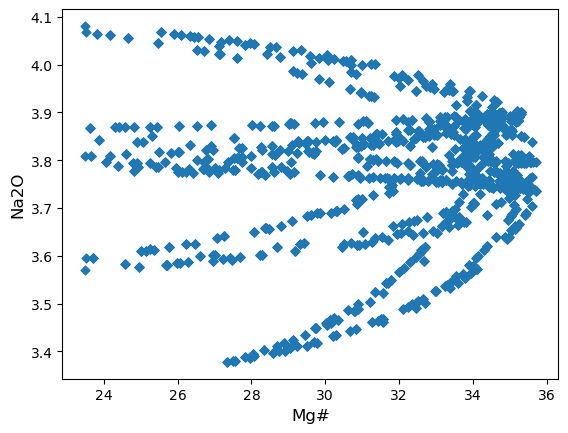

In [38]:
# 100 × (MgO / 40.304) / [(MgO / 40.304) + (FeOᵀ / 71.844)]
paired_liq_10_pass["Mg#"] = 100 * (paired_liq_10_pass["MgO"] / 40.304) / ((paired_liq_10_pass["MgO"] / 40.304) + (paired_liq_10_pass["FeO"] / 71.844))
paired_liq_10_pass.plot(x="Mg#", y="Na2O", kind="scatter")

C:\Users\13493\AppData\Local\Temp\ipykernel_68976\467681397.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  liq_2010_glass["Mg#"] = calculate_mg_number(liq_2010_glass)


<Axes: xlabel='Mg#', ylabel='Na2O'>

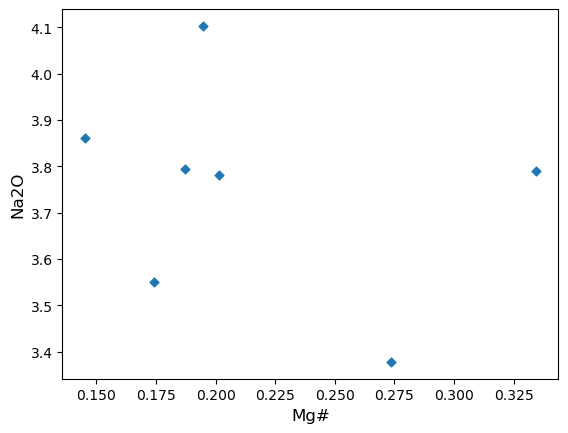

In [39]:
liq_2010_glass = liq_2010[liq_2010['glass/bulk']=="glass"]
liq_2010_glass["Mg#"] = calculate_mg_number(liq_2010_glass)
liq_2010_glass.plot(x="Mg#", y="Na2O", kind="scatter")

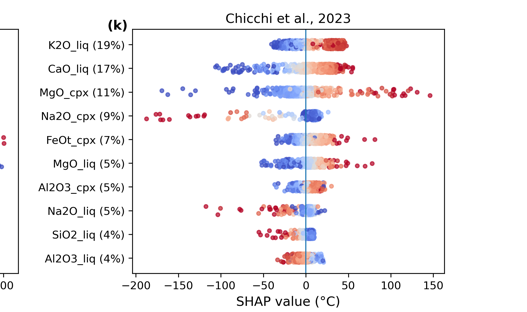